In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import matplotlib.pylab as plt

from sklearn.gaussian_process.kernels import RBF
from utils import ICMKernel
from abm.utils import _stack_tasks

In [ ]:
rng          = np.random.default_rng(42)
n_per_task   = 5
X_feat       = rng.uniform(-2, 2, size=(n_per_task, 2))  # two spatial dims
X            = np.vstack([np.c_[X_feat, np.zeros(n_per_task)],   # task 0
                         np.c_[X_feat + np.random.normal(loc=0, scale=1, size=X_feat.shape), np.ones (n_per_task)]])   # task 1
rho = 0.6

In [ ]:
X_out = np.array([0, 1])
Y_out = np.array([0, 1])
B = rho * (X_out[:, None] != Y_out[None, :]) + (
        X_out[:, None] == Y_out[None, :]
)

In [ ]:
B

In [ ]:
xi, yj = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1]), np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

In [ ]:
_B = np.array([[1, 0.6], [0.6, 1]])
print(_B)

In [ ]:
B[xi[:, None], yj[None, :]]

In [ ]:
_B[xi[:, None], yj[None, :]]

In [ ]:
xi[:, None]

In [ ]:
old_k = ICMKernel(length_scale=1.0, rho=0.6)

In [ ]:
K_old = old_k(X)

In [ ]:
plt.imshow(K_old)
plt.colorbar();

## Kernel illustration

In [ ]:
from rewards import sample_children_with_corr

In [ ]:
rho_child_child = 0.6
_, child_maps = sample_children_with_corr(
            rng=rng,
            n_children=4,
            length_scale=2.0,
            rho_parent_child=rho_child_child,
            rho_child_child=rho_child_child,
            tol=0.1,
            max_tries=1000,
            grid_size=11
        )

X = np.vstack([np.arange(11), np.zeros(11)]).T
rewards_1 = child_maps[0].mean(axis=1)
rewards_1 =  (rewards_1 - rewards_1.min()) / (rewards_1.max() - rewards_1.min())
rewards_2 = child_maps[1].mean(axis=1)
rewards_2 = (rewards_2 - rewards_2.min()) / (rewards_2.max() - rewards_2.min())
rewards_3 = child_maps[2].mean(axis=1)
rewards_3 = (rewards_3 - rewards_3.min()) / (rewards_3.max() - rewards_3.min())

X_full = _stack_tasks(X, [X, X])

fig, axes = plt.subplots(
    len([1.0, 2.0, 3.0]), len([-0.5, 0, 0.5, 1]), figsize=(12, 8),
    sharex=True, sharey=True
)
for i, ls in enumerate([1.0, 2.0, 3.0]):
    for j, rho in enumerate([-0.5, 0, 0.5, 1]):
        kernel = ICMKernel(length_scale=ls, rho=rho)
        K = kernel(X_full)
        ax = axes[i, j]
        im = ax.imshow(K, vmin=-1, vmax=1)
        ax.set_title(f"ls={ls}, $\\rho$={rho}")
        # ax.axis('off')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)
fig.savefig("icm_gp_kernel.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
idxs = [2, 5, 8]
X_obs_private = X[idxs]
y_obs_private = rewards_1[idxs]
idxs = [1, 4, 9]
X_obs_social1 = X[idxs]
y_obs_social1 = rewards_2[idxs]
idxs = [3, 7, 10]
X_obs_social2 = X[idxs]
y_obs_social2 = rewards_3[idxs]

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor

x_all = _stack_tasks(X_obs_private, [X_obs_social1, X_obs_social2])
y_all = np.concatenate([y_obs_private, y_obs_social1, y_obs_social2])
X_pred = np.column_stack([X, np.zeros(len(X))])

fig, ax = plt.subplots(figsize=(8, 4))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, 4))
rhos = [-0.5, 0.0, 0.5, 1.0]

for i, rho in enumerate(rhos):
    kernel = ICMKernel(length_scale=2.0, rho=rho)
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-4, normalize_y=False)
    gpr.fit(x_all, y_all)
    mu, std = gpr.predict(X_pred, return_std=True)

    ax.plot(X, mu, label=f"$\\rho$={rho}", color=colors[i])
    ax.fill_between(np.arange(11), mu - std, mu + std, color=colors[i], alpha=0.2)

# Plot private observations
ax.scatter(x_all[:, 0], y_all, # color=x_all[:, 1], 
           marker='x', label="Private Obs")

ax.set_title("ICM-GP Posterior for Private Task\n(Effect of Varying $\\rho$)")
ax.set_xlabel("X")
ax.set_ylabel("Reward")
ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()


In [ ]:
x_all = _stack_tasks(X_obs_private, [X_obs_social1, X_obs_social2])
y_all = np.concatenate([y_obs_private, y_obs_social1, y_obs_social2])

# Predict only for the private task (task index 0)
X_pred = np.column_stack([X, np.zeros(len(X))])

# Prepare plot
fig, ax = plt.subplots(figsize=(8, 5))
# colors = plt.cm.viridis(np.linspace(0.1, 0.9, 4))
colors = plt.get_cmap('Dark2').colors[:4]
rhos = [-0.5, 0.0, 0.5, 1.0]

# GP predictions with ICM for different rho
for i, rho in enumerate(rhos):
    kernel = ICMKernel(length_scale=2.0, rho=rho)
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-4, normalize_y=False, optimizer=None)
    gpr.fit(x_all, y_all)
    mu, std = gpr.predict(X_pred, return_std=True)

    ax.plot(np.arange(11), mu, label=f"$\\rho$={rho}", color=colors[i])
    ax.fill_between(np.arange(11), mu - std, mu + std, color=colors[i], alpha=0.2)

# Plot private and social observations with distinct markers/colors
plotted_labels = set()
for x, y, task in zip(x_all[:, 0], y_all, x_all[:, 2].astype(int)):
    if task == 0:
        label = "Private Obs" if "Private Obs" not in plotted_labels else None
        ax.scatter(x, y, marker='x', color='black', label=label)
        plotted_labels.add("Private Obs")
    elif task == 1:
        label = "Social 1 Obs" if "Social 1 Obs" not in plotted_labels else None
        ax.scatter(x, y, marker='o', edgecolors='blue', facecolors='none', label=label)
        plotted_labels.add("Social 1 Obs")
    elif task == 2:
        label = "Social 2 Obs" if "Social 2 Obs" not in plotted_labels else None
        ax.scatter(x, y, marker='s', edgecolors='orange', facecolors='none', label=label)
        plotted_labels.add("Social 2 Obs")

# Formatting
ax.set_title("ICM-GP Posterior for Private Task\n(Effect of Varying $\\rho$)")
ax.set_xlabel("X")
ax.set_ylabel("Reward")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=True)
plt.tight_layout()
plt.show()

In [ ]:
colors = plt.get_cmap('Dark2').colors[:4]
rhos = [-0.5, 0.5, 1.0]
X = np.vstack([np.arange(11), np.zeros(11)]).T

# Normalize helper
normalize = lambda x: (x - np.min(x)) / (np.max(x) - np.min(x))

# Assume rewards_1/2/3 are from child_maps[0:3] or similar
# Normalize to [0, 1]
rewards_1 = normalize(rewards_1)
rewards_2 = normalize(rewards_2)
rewards_3 = normalize(rewards_3)

# Observations
idxs = [2,  8]
X_obs_private = X[idxs]
y_obs_private = rewards_1[idxs]
idxs = [1, 9]
X_obs_social1 = X[idxs]
y_obs_social1 = rewards_2[idxs]
idxs = [3,  10]
X_obs_social2 = X[idxs]
y_obs_social2 = rewards_3[idxs]

# Stack training data
x_all = _stack_tasks(X_obs_private, [X_obs_social1, X_obs_social2])
y_all = np.concatenate([y_obs_private, y_obs_social1, y_obs_social2])

# Predict only for the private task (task index 0)
X_pred = np.column_stack([X, np.zeros(len(X))])

# --- Create two-panel figure ---
fig, axs = plt.subplots(1, 2, figsize=(12, 7), sharey=True)

# ==== LEFT: ICM-GP Posterior Predictions ====
ax = axs[0]
for i, rho in enumerate(rhos):
    kernel = ICMKernel(length_scale=2.0, rho=rho)
    gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-1, normalize_y=False, optimizer=None)
    gpr.fit(x_all, y_all)
    mu, std = gpr.predict(X_pred, return_std=True)

    # Clip to [0, 1] range to match true rewards
    mu = np.clip(mu, 0, 1)
    std = np.minimum(std, 1)  # optional

    ax.plot(X[:, 0].ravel(), mu, label=f"$\\rho$={rho}", color=colors[i])
    ax.fill_between(X[:, 0].ravel(), np.maximum(0, mu - std / 2), np.minimum(1, mu + std / 2), color=colors[i], alpha=0.2)

# Add observations
plotted_labels = set()
for x, y, task in zip(x_all[:, 0], y_all, x_all[:, 2].astype(int)):
    if task == 0:
        label = "Private Obs" if "Private Obs" not in plotted_labels else None
        ax.scatter(x, y, marker='x', color='black', label=label)
        plotted_labels.add("Private Obs")
    elif task == 1:
        label = "Social 1 Obs" if "Social 1 Obs" not in plotted_labels else None
        ax.scatter(x, y, marker='o', edgecolors='blue', facecolors='none', label=label)
        plotted_labels.add("Social 1 Obs")
    elif task == 2:
        label = "Social 2 Obs" if "Social 2 Obs" not in plotted_labels else None
        ax.scatter(x, y, marker='s', edgecolors='orange', facecolors='none', label=label)
        plotted_labels.add("Social 2 Obs")

ax.set_title("ICM-GP Posterior Mean for Private Task")
ax.set_xlabel("X")
ax.set_ylabel("Reward")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)

# ==== RIGHT: Ground Truth Reward Landscapes ====
ax2 = axs[1]
ax2.plot(X[:, 0].ravel(), rewards_1, color='black', label="Private", linestyle='-')
ax2.plot(X[:, 0].ravel(), rewards_2, color='blue', label="Social 1", linestyle='--')
ax2.plot(X[:, 0].ravel(), rewards_3, color='orange', label="Social 2", linestyle=':')

ax2.set_title("True Reward Landscapes")
ax2.set_xlabel("X")
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)

plt.suptitle("GP Posterior vs. True Reward Landscapes", fontsize=14)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
fig.savefig("icm_gp_vs_true_rewards.png", dpi=300, bbox_inches="tight")
plt.show()

## SG vs SG-ICM covariance

In [ ]:
from rewards import build_corr_matrix_option1, generate_env
from sklearn.gaussian_process.kernels import RBF

corr_matrix = build_corr_matrix_option1()
rho_true = corr_matrix[0]
grid_size = 11

parent, child_maps = generate_env(24, rho_true, corr_matrix, grid_size=grid_size)

In [ ]:
X = np.vstack([np.arange(11), np.zeros(11)]).T

fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True)

X_full = _stack_tasks(X, [X, X, X])

kernel = ICMKernel(length_scale=1.11, rho=rho_true)
K = kernel(X_full)
im = axes[1].imshow(K, vmin=-1, vmax=1)
axes[1].set_title("SCALE calibrated")

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6])
fig.colorbar(im, cax=cbar_ax)
# fig.savefig("icm_gp_kernel.png", dpi=300, bbox_inches="tight")
plt.show()

In [115]:
def plot_extended_visualization():
    # --- SETUP ---
    rhos = [0.6, 0.0, -0.6]
    n_points = 11
    X = np.vstack([np.arange(n_points), np.zeros(n_points)]).T

    X_full = _stack_tasks(X, [X, X, X])

    spatial_kernel = RBF(length_scale=1.11)
    K_spatial = spatial_kernel(X)

    # --- CONSTRUCT MATRICES ---

    # 1. SG Model
    B_sg = np.ones((4, 4))
    K_sg = np.kron(B_sg, K_spatial)

    # Calibrated noises:
    # Peer 1 (Rho 0.6) -> Low Noise (trusted)
    # Peer 2 (Rho 0.0) -> High Noise (ignored)
    # Peer 3 (Rho -0.6) -> High Noise (ignored)
    sg_peer_noises = [0.01, 20.0, 20.0]

    noise_sg = np.zeros_like(K_sg)
    np.fill_diagonal(noise_sg, 0.001) # Learner base noise

    for i, noise_val in enumerate(sg_peer_noises):
        peer_idx = i + 1
        start = peer_idx * n_points
        end = (peer_idx + 1) * n_points
        noise_sg[start:end, start:end] += np.eye(n_points) * noise_val

    Cov_SG = K_sg + noise_sg

    # 2. SCALE Model
    B_scale = np.eye(4)
    B_scale[0, 1] = B_scale[1, 0] = rhos[0]
    B_scale[0, 2] = B_scale[2, 0] = rhos[1]
    B_scale[0, 3] = B_scale[3, 0] = rhos[2]

    Cov_SCALE = np.kron(B_scale, K_spatial)
    Cov_SCALE += np.eye(Cov_SCALE.shape[0]) * 0.001

    # --- NORMALIZATION TO CORRELATION ---
    # Normalize Covariance to Correlation to ensure values are in [-1, 1] range.
    # This makes the visualization interpretable and prevents high-variance blocks
    # from saturating the colorbar or appearing deceptively strong.
    def to_correlation(cov):
        d = np.sqrt(np.diag(cov))
        # Outer product to divide by sigma_i * sigma_j
        return cov / np.outer(d, d)

    Corr_SG = to_correlation(Cov_SG)
    Corr_SCALE = to_correlation(Cov_SCALE)

    # --- PLOTTING ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    matrices = [Corr_SG, Corr_SCALE]
    titles = ["SG Calibrated",
              "SCALE Calibrated"]

    # Specific Labels for each model
    labels_sg = ["SG", "AS Peer 1\nLow Noise\n$\\varepsilon_\\text{soc}=0.01$", "AS Peer 2\nHigh Noise\n$\\varepsilon_\\text{soc}=20$", "AS Peer 3\nHigh Noise\n$\\varepsilon_\\text{soc}=20$"]
    labels_scale = ["SCALE", f"AS Peer 1\n($\\rho={rhos[0]}$)", f"AS Peer 2\n($\\rho={rhos[1]}$)", f"AS Peer 3\n($\\rho={rhos[2]}$)"]

    ticks = [n_points/2 + i*n_points for i in range(4)]

    for i, ax in enumerate(axes):
        im = ax.imshow(matrices[i], cmap='RdBu_r', vmin=-1, vmax=1)
        ax.set_title(titles[i], fontsize=16, fontweight='bold', pad=15)

        # Apply specific labels
        current_labels = labels_sg if i == 0 else labels_scale
        ax.set_xticks(ticks)
        ax.set_xticklabels(current_labels, fontsize=14)
        ax.set_yticks(ticks)
        ax.set_yticklabels(current_labels, fontsize=14, rotation=90, va='center')

        # Grid lines
        for j in range(1, 4):
            line_pos = j * n_points - 0.5
            ax.axhline(line_pos, color='k', linewidth=1, linestyle='-')
            ax.axvline(line_pos, color='k', linewidth=1, linestyle='-')

        # --- VISUALIZING SPATIAL ASPECT ---
        # Draw small arrows/labels inside the top-left block (Learner self-block)
        # to explain the 'texture' inside the blocks is Spatial.

        # Arrow for Spatial x (horizontal)
        ax.arrow(1, 1, 8, 0, head_width=0.8, head_length=0.8, fc='black', ec='black')
        ax.text(6, 0.5, "Spatial ($x$)", ha='center', va='bottom', fontsize=8, fontweight='bold')

        # Arrow for Spatial x' (vertical)
        ax.arrow(1, 1, 0, 8, head_width=0.8, head_length=0.8, fc='black', ec='black')
        ax.text(0.5, 6, "Spatial ($x'$)", ha='center', va='center', rotation=90, fontsize=8, fontweight='bold')

        # Text explaining the hierarchy
        ax.text(n_points * 2, -1, "Inner Gradient: Spatial Decay (RBF Kernel)",
                ha='center', fontsize=9, style='italic', color='#333333')

    # Colorbar
    # fig.subplots_adjust(right=0.85, wspace=0.3)
    # cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
    # fig.colorbar(im, cax=cbar_ax)

    # --- ANNOTATIONS ---

    def annotate(ax, r, c, text, color="black", bg_alpha=0.6):
        x = c * n_points + n_points/2
        y = r * n_points + n_points/2
        ax.text(x, y, text, ha='center', va='center',
                fontsize=14, fontweight='bold', color=color,
                bbox=dict(facecolor='white', alpha=bg_alpha, edgecolor='none', pad=1))

    # Annotate SG (Left Plot)
    ax_sg = axes[0]
    # # SG assumes rho=1 (red), but noise dampens it
    # annotate(ax_sg, 0, 1, "Assumed $\\rho=1$\nLow Noise")
    # annotate(ax_sg, 0, 2, "Assumed $\\rho=1$\nHigh Noise\n($\\downarrow$ Eff. Corr)", color="#555555")
    # annotate(ax_sg, 0, 3, "Assumed $\\rho=1$\nHigh Noise\n($\\downarrow$ Eff. Corr)", color="#555555")
    #
    # # Annotate SCALE (Right Plot)
    # ax_scale = axes[1]
    # annotate(ax_scale, 0, 1, "Learned\nRho=+0.6")
    # annotate(ax_scale, 0, 2, "Learned\nRho=0.0")
    # annotate(ax_scale, 0, 3, "Learned\nRho=-0.6", color="#d62728")
    #
    # annotate(ax_scale, 1, 0, "+0.6")
    # annotate(ax_scale, 3, 0, "-0.6", color="#d62728")

    plt.tight_layout()
    fig.savefig("sg_scale_covariance.png", dpi=300, bbox_inches="tight")
    fig.savefig("sg_scale_covariance.svg", dpi=300, bbox_inches="tight")
    fig.savefig("sg_scale_covariance.pdf", dpi=300, bbox_inches="tight")
    plt.show()

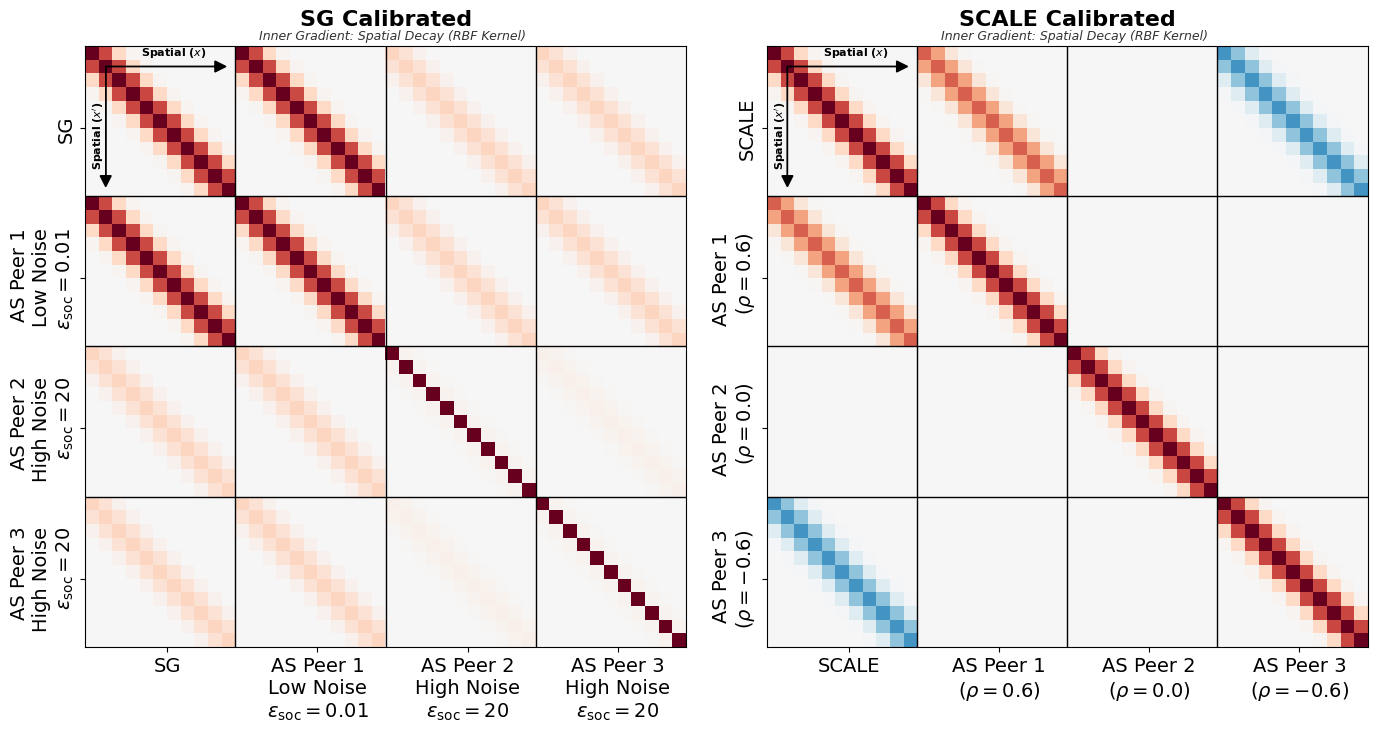

In [116]:
plot_extended_visualization()